In [ ]:
import pandas as pd
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
# plt.style.use('seaborn-whitegrid') # Plot style
plt.rcParams['figure.figsize'] = (12.0, 8.0)

from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from google.colab.patches import cv2_imshow

from tensorflow.keras import models
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

import datetime

## Data Processing

If you have noticed, the training data consists of raw images, which means that we need to process those images and construct a dataset (pd.DataFrame or np.array) where each row will be an image vector and the last column will be its corresponding label. Complete the missing parts of the code snippet below in order to construct the dataset.

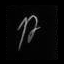

In [ ]:
img = cv2.imread('/content/drive/MyDrive/ML/Train/Train/8/2.png')
cv2_imshow(img)

In [ ]:
root_dir = "Train"

# getting the list of folder names (label encodings)
sub_folders = os.listdir(root_dir)
# empty list for the data
train = []
batch_size = 15000
# going over the folders
for sub_folder in sub_folders:

  # getting the list of image names in each folder
  images = os.listdir(os.path.join(root_dir, sub_folder))

  # going over the images
  for image_name in images:

    folder_path = f'Train/Train/{image_name}/'  # Folder containing images

    # Get all image filenames in the folder
    image_files = sorted([f for f in os.listdir(folder_path) if f.endswith(".png")])
    batch = []
    # reading the image
    for image_file in image_files:
      image_path = os.path.join(folder_path, image_file)  # Construct full path
      image = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)

      feature_vector = image.reshape(4096)


    # now we need to add the resulting feature vector and
    # its label (here its the sub_folder name) into the train list
      batch.append([*feature_vector, int(image_name)])
      print(image_file)
      if len(batch) >= batch_size:
            train.append(pd.DataFrame(batch))  # Convert batch to DataFrame & store
            batch = []  # Reset batch
    if batch:
        train.append(pd.DataFrame(batch))

Have a look the resulting data

In [ ]:
train_df = pd.concat(train, ignore_index=True)

train_df.shape

(70060, 4097)

It's a good idea to save the processed dataset in your Drive, so that you don't need go through the above process every time.

In [ ]:
train_df.to_csv('train.csv', index=False)

In [ ]:
train_df = pd.read_csv('train.csv')

In [ ]:
train_df.shape

(70060, 4097)

In [ ]:
train_df.head()

,0,1,2,3,4,5,6,7,8,9,...,4087,4088,4089,4090,4091,4092,4093,4094,4095,4096
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Constructing a Validation set

Since you do not have a separate labeled test data for validation, you should construct (put aside) your own validation set from the whole training data, in order to choose good models.
You are free to decide how much data you will use for what purposes, but remember to use data wisely.

In [ ]:
X = train_df.iloc[:, :-1]  # All columns except the last one (features)
y = train_df.iloc[:, -1]   # Last column (labels)

In [ ]:
X.shape

(70060, 4096)

In [ ]:
y.shape

(70060,)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.23, random_state=42, shuffle=True)

In [ ]:
X_train.values

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [ ]:
# making X_train shape from (4096,) to (64,64) for CNN

X_train_for_cnn = X_train.values.reshape(-1, 64, 64)
X_test_for_cnn = X_test.values.reshape(-1, 64, 64)


## Modelling

Perform experiments with different algorithms that we have learned and choose a good algorithm for final evaluation.

In [ ]:
# CNN

model = models.Sequential()

# Convolutional layers
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 1)))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.2))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.3))

model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.4))

model.add(layers.Flatten())
# Fully Connected Layer
model.add(layers.Dense(128, activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.4))

# Output Layer (78 classes)
model.add(layers.Dense(78, activation='softmax'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 78)             │        10,062 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 694,094 (2.65 MB)

 Trainable params: 693,390 (2.65 MB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:
early_stop = EarlyStopping(
    patience=5,             # Number of epochs with no improvement after which training stops
    restore_best_weights=True,  # Restores model weights from the epoch with the best value of the monitored metric
    verbose=1
)

In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(X_train_for_cnn, y_train, epochs=30,
                    validation_data=(X_test_for_cnn, y_test),
                    callbacks=[early_stop])

Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/nn.py:708: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1686/1686 ━━━━━━━━━━━━━━━━━━━━ 88s 12ms/step - accuracy: 0.8848 - loss: 0.3720 - val_accuracy: 0.9234 - val_loss: 0.2624
Epoch 2/30
1686/1686 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8901 - loss: 0.3603 - val_accuracy: 0.9345 - val_loss: 0.2325
Epoch 3/30
1686/1686 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.8973 - loss: 0.3322 - val_accuracy: 0.9279 - val_loss: 0.2379
Epoch 4/30
1686/1686 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9003 - loss: 0.3214 - val_accuracy: 0.9369 - val_loss: 0.2212
Epoch 5/30
1686/1686 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9028 - loss: 0.3076 - val_accuracy: 0.9335 - val_loss: 0.2283
Epoch 6/30
1686/1686 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9058 - loss: 0.2980 - val_accuracy: 0.9445 - val_loss: 0.1950
Epoch 7/30
1686/1686 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9091 - loss: 0.2911 - val_accuracy: 0.9353 - val_loss: 0.2203
Epoch 8/30
1686/1686 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9114 - loss: 0.2812 - va

In [ ]:
model.save("convolutional_neural_network.h5")

In [ ]:
# Dense neural network

model = tf.keras.Sequential([
    layers.Input(shape=(4096,)),
    layers.Dropout(0.4),
    layers.Dense(2048),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),
    layers.Dense(1024),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),
    layers.Dense(512),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),
    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dense(78, activation='softmax')
])

In [ ]:
cd /content/drive/MyDrive/ML/new_test/

/content/drive/MyDrive/ML/new_test


In [ ]:
model.save("dense_neural_network.h5")

In [ ]:
model = tf.keras.models.load_model("dense_neural_network.h5")

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2048)           │     8,390,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 78)             │        20,046 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,180,366 (42.65 MB)

 Trainable params: 11,172,686 (42.62 MB)

 Non-trainable params: 7,680 (30.00 KB)

In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])


history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_test, y_test),
                    callbacks=[early_stop])

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/nn.py:708: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1686/1686 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2127 - loss: 3.1668

/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/nn.py:708: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1686/1686 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - accuracy: 0.2128 - loss: 3.1665 - val_accuracy: 0.5353 - val_loss: 1.6179
Epoch 2/10
1686/1686 ━━━━━━━━━━━━━━━━━━━━ 30s 6ms/step - accuracy: 0.4501 - loss: 1.9254 - val_accuracy: 0.6365 - val_loss: 1.2459
Epoch 3/10
1686/1686 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.5319 - loss: 1.6039 - val_accuracy: 0.6909 - val_loss: 1.0557
Epoch 4/10
1686/1686 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.5859 - loss: 1.3932 - val_accuracy: 0.7229 - val_loss: 0.9328
Epoch 5/10
1686/1686 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.6281 - loss: 1.2485 - val_accuracy: 0.7517 - val_loss: 0.8365
Epoch 6/10
1686/1686 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.6539 - loss: 1.1432 - val_accuracy: 0.7577 - val_loss: 0.8093
Epoch 7/10
1686/1686 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6758 - loss: 1.0602 - val_accuracy: 0.7796 - val_loss: 0.7480
Epoch 8/10
1686/1686 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.6998 - loss: 0.9798 - val

## Generating predictions

At this stage you should have good performing model that you want to test on kaggle.

In [ ]:
cd /content/drive/MyDrive/ML/new_test/

/content/drive/MyDrive/ML/new_test


In [ ]:
ls

convolutional_neural_network.h5  gandz_net.h5  my_submission.csv
dense_neural_network.h5          logs/         new_test.csv


In [ ]:
test = pd.read_csv('new_test.csv')
test.head()

,0,1,2,3,4,5,6,7,8,9,...,4086,4087,4088,4089,4090,4091,4092,4093,4094,4095
0,0,0,4,0,0,0,0,0,0,0,...,0,0,3,0,0,2,0,1,0,2
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
test.shape

(50000, 4096)

**CNN model**

In [ ]:
model = tf.keras.models.load_model('convolutional_neural_network.h5')

In [ ]:
# Reshaping test for cnn

test_for_cnn = test.values.reshape(-1, 64, 64)

In [ ]:
test_for_cnn.shape

(50000, 64, 64)

In [ ]:
predictions = model.predict(test_for_cnn)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step


**Dense model**

In [ ]:
model = tf.keras.models.load_model('dense_neural_network.h5')

In [ ]:
predictions = model.predict(test)

In [ ]:
predictions.shape

(50000, 78)

In [ ]:
predictions

array([[2.0175644e-06, 6.8047241e-04, 1.4683740e-11, ..., 1.0974671e-03,
        9.6251606e-06, 1.0816322e-10],
       [2.8706787e-03, 3.3680621e-01, 1.0279843e-21, ..., 1.5375750e-05,
        2.5864603e-08, 2.9476341e-06],
       [1.1261230e-03, 1.0510816e-01, 6.7283676e-22, ..., 7.7078866e-08,
        1.5946918e-12, 1.0572719e-17],
       ...,
       [4.2860182e-05, 3.4822945e-02, 2.2365723e-24, ..., 1.1143748e-08,
        1.4565154e-16, 7.7934244e-26],
       [2.7278864e-18, 5.1411808e-01, 4.6891967e-30, ..., 5.3451698e-11,
        3.9020802e-14, 2.9702786e-18],
       [5.8069616e-04, 1.4668044e-01, 1.5530393e-11, ..., 7.1288078e-08,
        3.1221621e-09, 7.7890574e-09]], dtype=float32)

In [ ]:
predicted_labels = np.argmax(predictions, axis=1)

In [ ]:
predicted_labels

array([ 6, 21, 62, ..., 21,  1, 71])

In [ ]:
predicted_labels.shape

(50000,)

In [ ]:
submission_df = pd.DataFrame({'Id': np.arange(1, test.shape[0]+1),
                              'Category': predicted_labels})
submission_df.to_csv('my_submission.csv', index=False)

* Download the generated ``my_submission.csv`` file and upload it to kaggle by pressing "Submit predictions" and following the steps.

* You have to describe your submission under the "Describe Submission" section with some details about the algorithm/hyperparameters that you used

* After the submission you will see the accuracy of your model and your position in the public leaderboard

* You can only submit 5 files per day

# Test on several images

In [ ]:
first_test_data = np.array(test.iloc[123])
first_test_data

array([0, 0, 0, ..., 0, 0, 0])

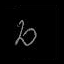

In [ ]:
cv2_imshow(first_test_data.reshape(64, 64))

In [ ]:
first_test_data = first_test_data.reshape(-1, 64, 64)

In [ ]:
a = tf.nn.softmax(model(first_test_data))

In [ ]:
x = a.numpy()

In [ ]:
max_element = np.max(x)

In [ ]:
max_element

np.float32(0.028725617)

In [ ]:
for i in range(78):
  if x[0][i] == max_element:
    print(i)

18
